<a href="https://colab.research.google.com/github/cursuri-inf/IPAP/blob/main/saptamana-02/curs02_demonstratii.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cursul 2. Demonstrațiile

Caietul conține demonstrațiile de la cursul 2, „Fluxul unui proiect de învățare automată”, cu rezultatele salvate. Codul este cel din suportul de curs, iar titlurile de mai jos au numerele secțiunilor din suport. Ordinea este a suportului, cu o singură excepție: salvarea modelului (§7.1) vine după fluxul complet (§9), pentru că folosește arborele antrenat acolo.

**Cum lucrezi:**

1. Deschizi caietul cu butonul „Open in Colab” de mai sus. Colab avertizează că documentul nu a fost creat de Google: caietul vine din depozitul cursului, așa că alegi „Run anyway”.
2. Înainte să schimbi ceva: File → Save a copy in Drive; lucrezi în copie.
3. Rezultatele salvate se văd și fără rulare. Ca să le obții din nou, rulezi celulele în ordine, de sus în jos, cu Shift+Enter.
4. Apoi schimbi câte ceva (un număr, o coloană, o condiție), rulezi din nou și compari cu ce scrie în suport.
5. Notițele tale: după fiecare demonstrație ai o celulă „Notițele mele” (dublu clic ca s-o editezi). Poți lăsa și comentarii pe marginea din dreapta a oricărei celule: clic dreapta pe celulă, apoi „Add a comment” (sau Ctrl+Alt+M).

Caietul rulează pe procesor; un GPU nu este necesar. Nu se predă și nu se notează.

## 0. Pornire: versiunile (§7.2)

Prima celulă a oricărui caiet afișează versiunile bibliotecilor, ca rezultatele să poată fi refăcute. În alte versiuni, unele cifre pot diferi la ultima zecimală.

In [1]:
import sys, numpy, pandas, sklearn

print(sys.version.split()[0], numpy.__version__,
      pandas.__version__, sklearn.__version__)
# aceeași sămânță peste tot:
# la împărțire și la model
SEED = 0

3.13.13 2.2.6 2.2.3 1.6.1


## D1. Antrenarea este o buclă (§5.3)

Modelul masa = a × lungimea aripii, cu un singur parametru, pe cinci pinguini. Bucla încearcă puțin mai mult și puțin mai puțin și păstrează doar ce scade pierderea.

In [2]:
import numpy as np

# lungimea aripii (mm) și masa reală (g)
x = np.array([181, 186, 195, 193, 190])
y = np.array([3750, 3800, 3250, 3450, 3650])

def eroare(a):  # pierderea: eroarea absolută medie
    return np.mean(np.abs(a * x - y))

a, pas = 10.0, 0.5   # punctul de plecare și pasul
for i in range(20):
    # puțin mai mult, puțin mai puțin
    for nou in (a + pas, a - pas):
        # păstrăm doar ce scade pierderea
        if eroare(nou) < eroare(a):
            a = nou
    print(i, a, round(eroare(a)))

0 10.5 1596
1 11.0 1501
2 11.5 1406
3 12.0 1312
4 12.5 1218
5 13.0 1123
6 13.5 1028
7 14.0 934
8 14.5 840
9 15.0 745
10 15.5 650
11 16.0 556
12 16.5 462
13 17.0 393
14 17.5 338
15 18.0 292
16 18.5 275
17 19.0 258
18 19.0 258
19 19.0 258


### Schimbați pasul

Aceeași buclă, cu alt pas. Prevedeți întâi: cu pasul 5, unde ajunge a după 20 de repetări? Dar cu pasul 0,1? Apoi rulați și comparați cu secțiunea 5.3.

In [3]:
def cauta(pas, a=10.0, repetari=20):
    for i in range(repetari):
        for nou in (a + pas, a - pas):
            if eroare(nou) < eroare(a):
                a = nou
    return round(a, 1), round(eroare(a))

print(round(eroare(10.0)))   # pierderea la pornire
for pas in (5, 0.5, 0.1):
    print(pas, cauta(pas))

1690
5 (20.0, 284)
0.5 (19.0, 258)
0.1 (12.0, 1312)


### Notițele mele

…

## D2. Python științific prin exemple (§8)

### Tablouri numpy și forma lor (§8.1)

In [4]:
import numpy as np

# masele, în grame
masa = np.array([3750, 3800, 3250, 3450, 3650])
print(masa.shape)    # o singură axă, cu 5 valori
print(masa.dtype)    # numere întregi
print(masa.mean(), masa.max())

(5,)
int64
3580.0 3800


In [5]:
X = np.array([[39.1, 18.7, 181, 3750],
              [39.5, 17.4, 186, 3800],
              [40.3, 18.0, 195, 3250]])
# 3 exemple, 4 trăsături
print(X.shape)
# primul rând: primul pinguin
print(X[0])
# a treia coloană: lungimea aripii, la toți
print(X[:, 2])
# al doilea pinguin, a patra coloană: masa
print(X[1, 3])
# media fiecărei coloane
print(X.mean(axis=0).round(1))

(3, 4)
[  39.1   18.7  181.  3750. ]
[181. 186. 195.]
3800.0
[  39.6   18.   187.3 3600. ]


### Operații vectorizate și indexare (§8.2)

In [6]:
print(masa / 1000)
print(masa > 3500)
print(masa[masa > 3500])
# câți pinguini au peste 3.500 g
print((masa > 3500).sum())

[3.75 3.8  3.25 3.45 3.65]
[ True  True False False  True]
[3750 3800 3650]
3


In [7]:
medii = X.mean(axis=0)
abateri = X.std(axis=0)
# fiecare coloană are acum media 0 și abaterea 1
Z = (X - medii) / abateri

Verificare: după standardizare, fiecare coloană are media 0 și abaterea 1.

In [8]:
print(Z.mean(axis=0).round(6) + 0)
print(Z.std(axis=0).round(6))

[0. 0. 0. 0.]
[1. 1. 1. 1.]


### Citirea unui tabel cu pandas (§8.3)

In [9]:
import pandas as pd

URL = ("https://raw.githubusercontent.com/mwaskom/"
       "seaborn-data/master/penguins.csv")
df = pd.read_csv(URL)
print(df.shape)   # (344, 7)
# în Colab: un tabel cu primele 5 rânduri
df.head()

(344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [11]:
df.describe().round(1)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.0,342.0,342.0,342.0
mean,43.9,17.2,200.9,4201.8
std,5.5,2.0,14.1,802.0
min,32.1,13.1,172.0,2700.0
25%,39.2,15.6,190.0,3550.0
50%,44.4,17.3,197.0,4050.0
75%,48.5,18.7,213.0,4750.0
max,59.6,21.5,231.0,6300.0


### Selecție, valori lipsă, grupare (§8.4)

Celula afișează doar rezultatul ultimului rând. Ca să vedeți și celelalte, rulați-le pe rând, fiecare în celula ei.

In [12]:
# o coloană
df["species"]
# mai multe coloane: o listă de nume
df[["bill_length_mm", "body_mass_g"]]
# rândurile care îndeplinesc o condiție
df[df["body_mass_g"] > 5500]
# câte valori lipsesc în fiecare coloană
df.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [13]:
# cei 2 pinguini fără nicio măsurătoare
df = df.dropna(subset=["body_mass_g"])
print(df.shape)
print(df["species"].value_counts())

(342, 7)
species
Adelie       151
Gentoo       123
Chinstrap     68
Name: count, dtype: int64


In [14]:
df.groupby("species")["body_mass_g"].mean().round()

species
Adelie       3701.0
Chinstrap    3733.0
Gentoo       5076.0
Name: body_mass_g, dtype: float64

### Un grafic rapid cu matplotlib (§8.5)

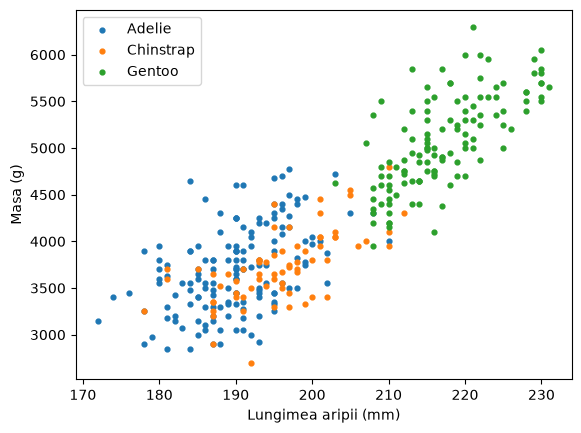

In [15]:
import matplotlib.pyplot as plt

for specie, grup in df.groupby("species"):
    plt.scatter(grup["flipper_length_mm"],
                grup["body_mass_g"],
                s=12, label=specie)
plt.xlabel("Lungimea aripii (mm)")
plt.ylabel("Masa (g)")
plt.legend()
plt.show()

In [16]:
# aripa cea mai scurtă la Gentoo
print(df[df["species"] == "Gentoo"]
      ["flipper_length_mm"].min())

203.0


### Notițele mele

…

## D3. Fluxul complet pe un exemplu mic (§9)

Întrebarea: ce specie este pinguinul, după cele patru măsurători? Celulele se rulează în ordine; fiecare corespunde unui pas din flux.

### Întrebarea și datele (§9.1)

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_text
from sklearn.metrics import confusion_matrix

URL = ("https://raw.githubusercontent.com/mwaskom/"
       "seaborn-data/master/penguins.csv")
df = pd.read_csv(URL)
masuri = ["bill_length_mm", "bill_depth_mm",
          "flipper_length_mm", "body_mass_g"]
# 342 de pinguini cu toate măsurătorile
df = df.dropna(subset=masuri)
# trăsăturile și eticheta
X, y = df[masuri], df["species"]

### Împărțirea (§9.2)

In [18]:
X_rest, X_test, y_rest, y_test = train_test_split(
    X, y, test_size=0.15,
    stratify=y, random_state=0)
X_ant, X_val, y_ant, y_val = train_test_split(
    X_rest, y_rest, test_size=0.15 / 0.85,
    stratify=y_rest, random_state=0)
print(len(X_ant), len(X_val),
      len(X_test))  # 238 52 52

238 52 52


### Referința simplă (§9.3)

In [19]:
ref = DummyClassifier(strategy="most_frequent")
ref.fit(X_ant, y_ant)
print(ref.score(X_val, y_val))  # 0.4423076923076923

0.4423076923076923


### Modelul, ales pe validare (§9.4)

In [20]:
for d in range(1, 9):
    m = DecisionTreeClassifier(max_depth=d,
                               random_state=0)
    m.fit(X_ant, y_ant)
    print(d, round(m.score(X_ant, y_ant), 3),
          round(m.score(X_val, y_val), 3))

1 0.786 0.808
2 0.966 0.962
3 0.975 0.962
4 0.996 0.981
5 1.0 0.981
6 1.0 0.981
7 1.0 0.981
8 1.0 0.981


In [21]:
m2 = DecisionTreeClassifier(max_depth=2,
                            random_state=0)
m2.fit(X_ant, y_ant)
print(export_text(m2, feature_names=masuri))

|--- flipper_length_mm <= 206.50
|   |--- bill_length_mm <= 43.35
|   |   |--- class: Adelie
|   |--- bill_length_mm >  43.35
|   |   |--- class: Chinstrap
|--- flipper_length_mm >  206.50
|   |--- bill_depth_mm <= 17.65
|   |   |--- class: Gentoo
|   |--- bill_depth_mm >  17.65
|   |   |--- class: Chinstrap



### Evaluarea finală, pe test (§9.5)

In [22]:
m = DecisionTreeClassifier(max_depth=4,
                           random_state=0)
m.fit(X_ant, y_ant)
print(m.score(X_test, y_test))  # 0.9615384615384616
print(confusion_matrix(y_test, m.predict(X_test)))

0.9615384615384616
[[22  1  0]
 [ 1  9  0]
 [ 0  0 19]]


Cele două greșeli de pe test, cu măsurătorile lor și cu specia reală (secțiunea 9.5 le explică).

In [23]:
gresit = m.predict(X_test) != y_test
print(X_test[gresit])
print(y_test[gresit].tolist())

     bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
171            49.2           18.2              195.0       4400.0
73             45.8           18.9              197.0       4150.0
['Chinstrap', 'Adelie']


### Același flux, pentru o regresie (§9.6)

In [24]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error as mae)

Xr = df[["flipper_length_mm"]]
yr = df["body_mass_g"]
Xr_ant, Xr_test, yr_ant, yr_test = train_test_split(
    Xr, yr, test_size=0.2, random_state=0)

# prezice mereu media: 4.208 g
ref = DummyRegressor().fit(Xr_ant, yr_ant)
# masa ≈ a × aripa + b
lin = LinearRegression().fit(Xr_ant, yr_ant)
print(round(mae(yr_test, ref.predict(Xr_test))))
print(round(mae(yr_test, lin.predict(Xr_test))))
print(round(lin.coef_[0], 1), round(lin.intercept_))

619
314
49.4 -5722


In [25]:
# media maselor din antrenare: ce prezice referința
print(round(yr_ant.mean()))

4208


### Notițele mele

…

## D4. Salvarea modelului (§7.1)

Arborele `m`, de adâncime 4, antrenat în D3, se salvează într-un fișier și se încarcă din nou, fără reantrenare. În Colab, fișierul apare în panoul Files, din stânga.

In [26]:
import joblib

# salvează modelul antrenat
joblib.dump(m, "arbore_pinguini.joblib")
# îl încarcă, de exemplu într-o aplicație
m2 = joblib.load("arbore_pinguini.joblib")

In [27]:
# modelul încărcat dă aceeași acuratețe pe test
print(m2.score(X_test, y_test))

0.9615384615384616


### Notițele mele

…

## D5. Modelul preantrenat și înghețarea straturilor (§10.2)

Pregătirea laboratorului 2: ResNet-18 cu parametrii învățați pe ImageNet, cu toate straturile înghețate și cu ultimul strat înlocuit. Prima rulare descarcă parametrii (aproximativ 45 MB).

In [28]:
import torch.nn as nn
from torchvision.models import resnet18
from torchvision.models import ResNet18_Weights

# parametrii învățați pe ImageNet
model = resnet18(weights=ResNet18_Weights.DEFAULT)
# înghețăm toate straturile
for p in model.parameters():
    p.requires_grad = False
# ultimul strat nou: 512 intrări, 2 ieșiri
model.fc = nn.Linear(model.fc.in_features, 2)
print(sum(p.numel() for p in model.parameters()
          if p.requires_grad))  # 1026

1026


In [29]:
# toți parametrii rețelei adaptate
print(sum(p.numel() for p in model.parameters()))

11177538


### Notițele mele

…

## Mai departe

La laboratorul 2 antrenezi ultimul strat al acestei rețele pe fotografii de furnici și albine, în caietul L2. Pe traseul Rampă, caietul *Python științific* reia secțiunea D2, cu exerciții care se verifică singure; cursul Kaggle Learn *Pandas* face același lucru pe alte date.